In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [40]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy')
import fp_solvers as fps
import langevin_sindy as lg
import timecorr as tc
from stochastic_sim import stochastic_sim_EM
import sympy

In [4]:
def f(x1,x2):
    return np.array([(x1+5)*(x2-4), (x2+2)*(x1-3)])

def a(x1,x2):
    return np.array([0*x1 + 0.01,0*x2 + 0.01])

In [14]:
x1vec

array([-10.        ,  -9.31034483,  -8.62068966,  -7.93103448,
        -7.24137931,  -6.55172414,  -5.86206897,  -5.17241379,
        -4.48275862,  -3.79310345,  -3.10344828,  -2.4137931 ,
        -1.72413793,  -1.03448276,  -0.34482759,   0.34482759,
         1.03448276,   1.72413793,   2.4137931 ,   3.10344828,
         3.79310345,   4.48275862,   5.17241379,   5.86206897,
         6.55172414,   7.24137931,   7.93103448,   8.62068966,
         9.31034483,  10.        ])

In [27]:
Nx=30
Ny=20
bins = [np.linspace(-10,10,Nx+1),np.linspace(-10,10,Ny+1)]
dx = [bins[0][1]-bins[0][0], bins[1][1]-bins[1][0]]

centers = [0.5*(bins[0][1:]+bins[0][:-1]),0.5*(bins[1][1:]+bins[1][:-1])]

X1,X2=np.meshgrid(centers[0],centers[1])

In [28]:
f_true = f(X1,X2)
a_true = a(X1,X2)

(-9.5, 9.5)

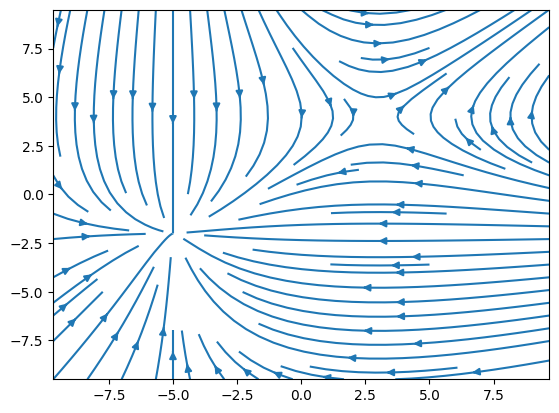

In [30]:
plt.streamplot(X1,X2,f_true[0],f_true[1])
plt.xlim([centers[0][0],centers[0][-1]])
plt.ylim([centers[1][0],centers[1][-1]])

In [31]:
fp = fps.SteadyFP((Nx,Ny), dx)
p_fit_true = fp.solve(f_true.swapaxes(1,2), a_true.swapaxes(1,2))

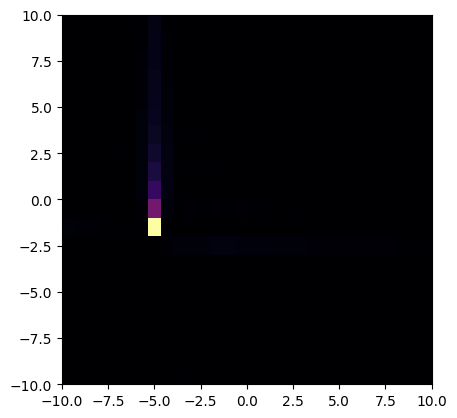

In [32]:
plt.imshow(p_fit_true.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]),vmin=0)

In [33]:
inits = np.random.uniform(low = [-10,-7.5], high = [0,2.5], size = (5000,2)).T
dt = 0.01
traj = stochastic_sim_EM(inits, lambda x: f(x[0],x[1]), lambda x: np.sqrt(2*a(x[0],x[1])), dt = dt, n_timepoints = 10000)

In [57]:
data_stationary = traj[:,-200:,:].reshape((2,-1))
my_idx = [i for i in range(data_stationary.shape[1]) if np.all(np.isfinite(data_stationary[:,i]))]

p_hist = np.histogram2d(data_stationary[0,my_idx],data_stationary[1,my_idx],bins,density=True)[0]

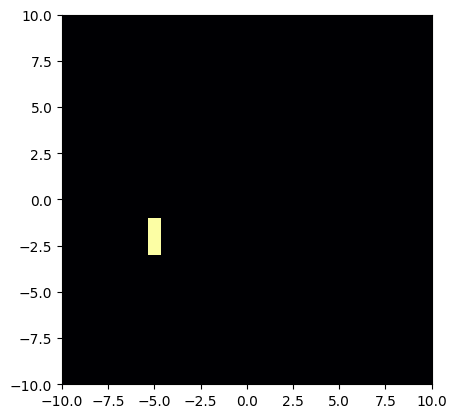

In [58]:
plt.imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]),vmin=0)

Next: pass data into Langevin SINDy 2D, debug that code 

In [44]:
stride = 5
X_t = np.swapaxes(traj,0,2)

num_traj = X_t.shape[0]
num_t = X_t.shape[1]
num_feats = X_t.shape[2]

data = [X_t[i,:,:2] for i in range(num_traj)] # high flow data, pass as list into KM_avg

## KM average (coarse grained subsampling)
f_fine, a_fine, _,_ = lg.KM_avg_2D(data, bins, stride=1, dt=dt, multi_traj=True)

f_coarse, a_coarse, _,_ = lg.KM_avg_2D(data, bins, stride=stride, dt=dt,multi_traj=True)

//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:109: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:110: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:111: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:112: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=-1)


In [ ]:
plt.scatter(X_t[:,:,0].flatten(),X_t[:,:,1].flatten(),s=0.1)

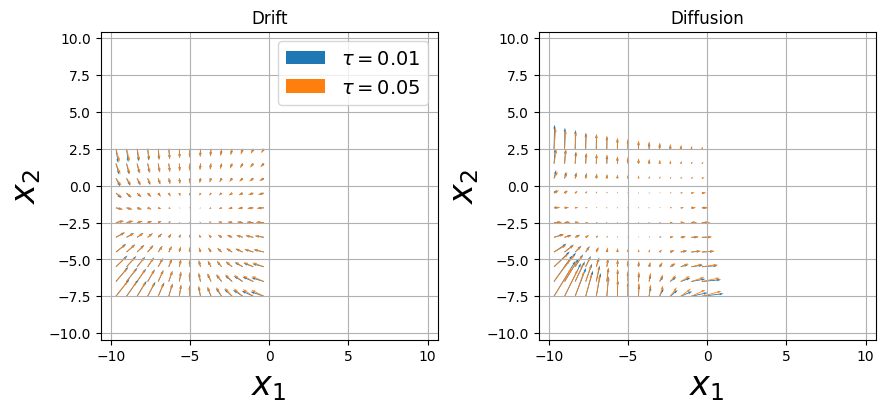

In [45]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.quiver(X1,X2, f_fine[:,:,0].T,f_fine[:,:,1].T,color=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.quiver(X1,X2, f_coarse[:,:,0].T,f_coarse[:,:,1].T,color=colors[1], label=r'$\tau=$'+str(np.round(dt*stride,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.quiver(X1,X2, a_fine[:,:,0].T,a_fine[:,:,1].T,color=colors[0])
plt.quiver(X1,X2, a_coarse[:,:,0].T, a_coarse[:,:,1].T, color=colors[1])
plt.title('Diffusion')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

In [48]:
tau = dt*np.arange(0, data[0].shape[0])
acf = np.zeros((len(tau),2,2))
for traj_idx in range(num_traj):
    acf = acf + tc.autocorr_func_2D(data[traj_idx])
acf = acf/num_traj

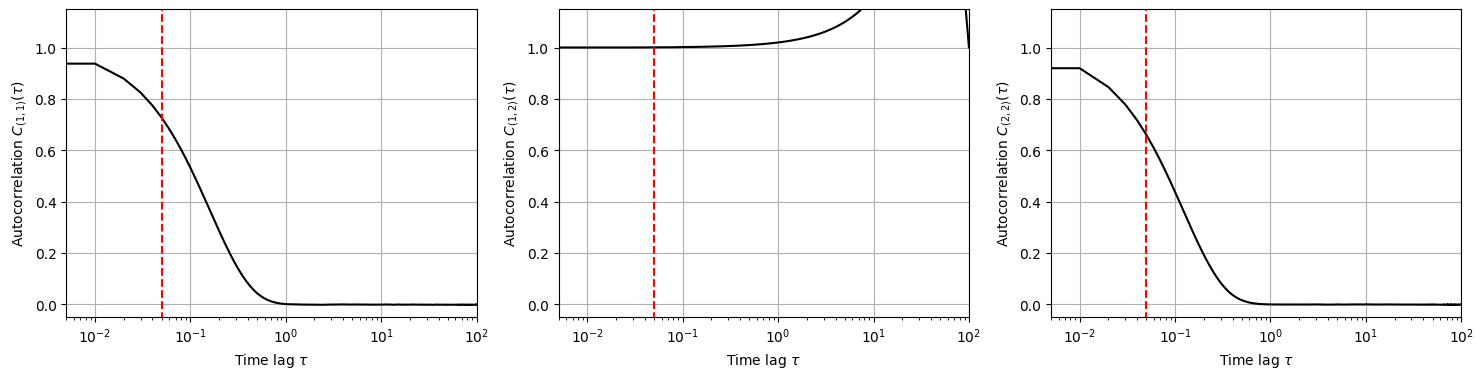

In [49]:
fig, axs = plt.subplots(1,3, figsize=(18, 4))
tup_list = [(0,0),(0,1),(1,1)]
for ii in range(3):
    i,j = tup_list[ii]
    axs[ii].plot(tau, acf[:,i,j], 'k')
    axs[ii].set_ylabel(r'Autocorrelation $C_{('+str(i+1)+','+str(j+1)+')}(\\tau)$')
    axs[ii].set_xlabel(r'Time lag $\tau$')
    axs[ii].vlines(stride*dt, acf.min()-0.1, acf.max()+0.1, 'r', '--')
    axs[ii].set_ylim([-0.05, 1.15])
    axs[ii].set_xlim([0.5*dt, 1e2])
    axs[ii].set_xscale('log')
    axs[ii].grid()

In [50]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_traj,len(lag)))
for loc_idx in range(num_traj):
    kl_div[loc_idx,:] = np.array([tc.markov_test(data[loc_idx][:,0], delta, N=Nx) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, np.max([np.nanmax(kl_div)+0.05,1])])
plt.grid()

In [66]:
### Build SINDy libraries with sympy
x1 = sympy.symbols('x1')
x2 = sympy.symbols('x2')

nf=2
ns=1
f_expr = np.tile(np.array([(x1**k)*(x2**(m-k)) for m in range(nf+1) for k in range(m+1)]),2)  # Polynomial library for drift
s_expr = np.tile(np.array([(x1**k)*(x2**(m-k)) for m in range(ns+1) for k in range(m+1)]),2)  # Polynomial library for diffusion

# Convert sympy expressions into library matrices
lib_f1 = np.zeros([len(f_expr)//2,Nx,Ny])
for k in range(len(f_expr)//2):
    lamb_expr = sympy.lambdify([x1,x2], f_expr[k])
    for i in range(Nx):
        for j in range(Ny):
            lib_f1[k,i,j] = lamb_expr(X1[j,i],X2[j,i])

lib_f2 = np.zeros([len(f_expr)//2,Nx,Ny])
for k in range(len(f_expr)//2):
    lamb_expr = sympy.lambdify([x1,x2], f_expr[k+len(f_expr)//2])
    for i in range(Nx):
        for j in range(Ny):
            lib_f2[k,i,j] = lamb_expr(X1[j,i],X2[j,i])

lib_f1 = lib_f1.T.reshape(Nx*Ny,-1)
lib_f2 = lib_f2.T.reshape(Nx*Ny,-1)

lib_f = np.block([[lib_f1, np.zeros((Nx*Ny,len(f_expr)//2))], [np.zeros((Nx*Ny,len(f_expr)//2)),lib_f2]])

lib_s1 = np.zeros([len(s_expr)//2,Nx,Ny])
for k in range(len(s_expr)//2):
    lamb_expr = sympy.lambdify([x1,x2], s_expr[k])
    for i in range(Nx):
        for j in range(Ny):
            lib_s1[k,i,j] = lamb_expr(X1[j,i],X2[j,i])

lib_s2 = np.zeros([len(s_expr)//2,Nx,Ny])
for k in range(len(s_expr)//2):
    lamb_expr = sympy.lambdify([x1,x2], s_expr[k+len(s_expr)//2])
    for i in range(Nx):
        for j in range(Ny):
            lib_s2[k,i,j] = lamb_expr(X1[j,i],X2[j,i])

lib_s1 = lib_s1.T.reshape(Nx*Ny,-1)
lib_s2 = lib_s2.T.reshape(Nx*Ny,-1)

lib_s = np.block([[lib_s1, np.zeros((Nx*Ny,len(s_expr)//2))], [np.zeros((Nx*Ny,len(s_expr)//2)),lib_s2]])

In [67]:
f_KM, a_KM, f_err, a_err = lg.KM_avg_2D(data, bins, stride=stride, dt=dt, multi_traj=True)

//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:109: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:110: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:111: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=-1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:112: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=-1)


In [68]:
# Initialize Xi with least squares regression (no finite-time corrections)

m=len(f_expr)+len(s_expr)
Xi0 = np.zeros(m)
mask = (np.where(np.isfinite(f_KM[:,:,0].flatten())*np.isfinite(f_KM[:,:,1].flatten())))[0]
n_mask = len(mask)
A1 = np.block([[lib_f1[mask], np.zeros((n_mask,len(f_expr)//2))], [np.zeros((n_mask,len(f_expr)//2)),lib_f2[mask]]])
b1 = np.hstack((f_KM[:,:,0].flatten()[mask],f_KM[:,:,1].flatten()[mask])).T
Xi0[:len(f_expr)] = np.linalg.lstsq(A1, b1, rcond=None)[0]   # Regression against drift

mask = (np.where(np.isfinite(a_KM[:,:,0].flatten())*np.isfinite(a_KM[:,:,1].flatten())))[0]
n_mask = len(mask)
A2 = np.block([[lib_s1[mask], np.zeros((n_mask,len(s_expr)//2))], [np.zeros((n_mask,len(s_expr)//2)),lib_s2[mask]]])
b2 = np.hstack((a_KM[:,:,0].flatten()[mask],a_KM[:,:,1].flatten()[mask])).T
Xi0[len(f_expr):] = np.linalg.lstsq(A2,b2, rcond=None)[0]  # Regression against diffusion a

### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.flatten(), a_err.flatten()))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())

# Initialize adjoint solver
afp = fps.AdjFP(centers,ndim=2)

# Initialize forward steady-state solver
fp = fps.SteadyFP((Nx,Ny), dx)

# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f, "lib_s": lib_s, "N": (Nx,Ny),
          "kl_reg": 10,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

# Use anonymous function to automatically pass the cost function
opt_fun = lambda params: lg.AFP_opt(lg.cost, params)

In [69]:
Xi, V = lg.SSR_loop(opt_fun, params)

%%%% Optimization time: 622.6096360683441 seconds,   Cost: 9.407374739497381 %%%%
[ 1  2  3  4  5  6  7  8  9 10 11]
[0 1 2 3 4 5]
[x2 x1 x2**2 x1*x2 x1**2 1 x2 x1 x2**2 x1*x2 x1**2] [1 x2 x1 1 x2 x1]
%%%% Optimization time: 575.4766685962677 seconds,   Cost: 14.30408226577401 %%%%
[ 0  2  3  4  5  6  7  8  9 10 11]
[0 1 2 3 4 5]
[1 x1 x2**2 x1*x2 x1**2 1 x2 x1 x2**2 x1*x2 x1**2] [1 x2 x1 1 x2 x1]
%%%% Optimization time: 600.5442502498627 seconds,   Cost: 13.726424661492945 %%%%
[ 0  1  3  4  5  6  7  8  9 10 11]
[0 1 2 3 4 5]
[1 x2 x2**2 x1*x2 x1**2 1 x2 x1 x2**2 x1*x2 x1**2] [1 x2 x1 1 x2 x1]
%%%% Optimization time: 627.859589099884 seconds,   Cost: 10.546402383227301 %%%%
[ 0  1  2  4  5  6  7  8  9 10 11]
[0 1 2 3 4 5]
[1 x2 x1 x1*x2 x1**2 1 x2 x1 x2**2 x1*x2 x1**2] [1 x2 x1 1 x2 x1]
%%%% Optimization time: 589.8755483627319 seconds,   Cost: 14.966638695642112 %%%%
[ 0  1  2  3  5  6  7  8  9 10 11]
[0 1 2 3 4 5]
[1 x2 x1 x2**2 x1**2 1 x2 x1 x2**2 x1*x2 x1**2] [1 x2 x1 1 x2 x1]
%%%